In [1]:
import os
import re
import io
import ipywidgets as widgets
from IPython.display import display
from pypdf import PdfReader
from nltk.corpus import stopwords
import pickle

def clean_text(text):
    """
    Clean text by removing unwanted characters and formatting.
    """
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII characters
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters and numbers
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    text = re.sub(r'\n+', '\n', text)  # Remove extra newlines
    return text


def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)


def preprocess_pdf(file_content, filename):
    """Extract and preprocess text from uploaded PDF file."""
    try:
        # Convert memoryview to BytesIO
        pdf_stream = io.BytesIO(file_content)

        reader = PdfReader(pdf_stream)
        extracted_text = ""
        for page in reader.pages:
            text = page.extract_text()
            if text:
                extracted_text += text + "\n"

        cleaned_text = clean_text(extracted_text)
        cleaned_text = remove_stop_words(cleaned_text)

        # Save cleaned text to file
        output_path = os.path.join(os.getcwd(), f"{filename}.txt")
        with open(output_path, "w", encoding="utf-8") as text_file:
            text_file.write(cleaned_text)

        print(f"Processed text saved to: {output_path}")
        print(f"Preview:\n{cleaned_text[:500]}...")  # Print first 500 chars

        # Save metadata for second script
        metadata = {
            "filename": filename,
            "file_path": output_path
        }
        with open("processed_file.pkl", "wb") as f:
            pickle.dump(metadata, f)

        print("Metadata saved for evaluation script.")

    except Exception as e:
        print(f"Error processing PDF: {e}")


# Upload Widget
upload_widget = widgets.FileUpload(
    accept='.pdf',  # Accept only PDF files
    multiple=False  # Only allow single file upload
)


def on_upload_change(change):
    """Handle file upload and process PDF."""
    if upload_widget.value:
        for file_info in upload_widget.value:
            filename = file_info['name'].replace(".pdf", "")
            file_content = file_info['content'].tobytes()  # Convert memoryview to bytes
            
            # Process PDF
            preprocess_pdf(file_content, filename)


# Attach event listener
upload_widget.observe(on_upload_change, names='value')

display(upload_widget)

FileUpload(value=(), accept='.pdf', description='Upload')

In [8]:
for file_info in upload_widget.value:
    print(file_info.name)

pillar3-disclosures-1q-2018.pdf


In [2]:
print(upload_widget.value)

({'name': 'pillar3-disclosures-1q-2018.pdf', 'type': 'application/pdf', 'size': 98305, 'content': <memory at 0x15230fac0>, 'last_modified': datetime.datetime(2025, 3, 1, 7, 48, 13, 135000, tzinfo=datetime.timezone.utc)},)


In [37]:
import os
import pickle
import json
import pandas as pd
import boto3
from botocore.config import Config
from dotenv import load_dotenv

load_dotenv("codes.env")

# AWS credentials
aws_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
aws_secret_key = os.environ.get("AWS_SECRET_ACCESS_KEY")
aws_region = os.environ.get("AWS_REGION")

# AWS Bedrock model configuration
MODEL_ID_LLAMA = "arn:aws:bedrock:us-west-2:874280117166:inference-profile/us.meta.llama3-3-70b-instruct-v1:0"

# Prevent Bedrock timeout
config = Config(read_timeout=1000)

client = boto3.client(
    "bedrock-runtime",
    region_name=aws_region,
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    config=config
)

# Load topic mappings
mapping_file_path = 'final_file_topic_mapping.csv'
file_topic_mapping = pd.read_csv(mapping_file_path)
unique_topics = file_topic_mapping['folder_name'].unique().tolist()
unique_topics_str = ', '.join(unique_topics)


def read_txt_file(file_path):
    """Reads the content of a .txt file."""
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            return file.read()
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None


def map_to_category(predicted_output):
    """Maps the model's output to a known category."""
    predicted_output = predicted_output.lower().strip()
    for topic in unique_topics:
        if topic.lower() in predicted_output:
            return topic
    return "unknown"


def evaluate_topic_with_llama(file_content):
    """Classify the text using AWS Bedrock (Meta's Llama 3.3 70B Instruct)."""
    try:
        prompt = f"Classify the following text into only one of these topics: {unique_topics_str}. \n{file_content}"
        formatted_prompt = f"""
            <|begin_of_text|>
            <|start_header_id|>user<|end_header_id|>
            {prompt}
            <|eot_id|>
            <|start_header_id|>assistant<|end_header_id|>
            """

        response = client.invoke_model(
            modelId=MODEL_ID_LLAMA,
            body=json.dumps({
                "prompt": formatted_prompt,
                "max_gen_len": 512,
                "temperature": 0,
            }),
            contentType="application/json"
        )
        response_body = json.loads(response['body'].read())
        predicted_topic = response_body.get("generation", "").strip()
        
        if not predicted_topic:
            print("Empty response from AWS Bedrock Llama, defaulting to unknown.")

        return map_to_category(predicted_topic)

    except Exception as e:
        print(f"Error calling AWS Bedrock API: {e}")
        return "unknown"


def evaluate_saved_file():
    """Loads metadata, reads file content, and evaluates it."""
    try:
        # Load metadata
        with open("processed_file.pkl", "rb") as f:
            metadata = pickle.load(f)

        filename = metadata["filename"]
        file_path = metadata["file_path"]

        print(f"Evaluating file: {filename}")

        # Read file content
        text_content = read_txt_file(file_path)
        if text_content:
            predicted_topic = evaluate_topic_with_llama(text_content)
            print(f"Predicted Topic: {predicted_topic}")
        else:
            print("Error: No content found in the file.")

    except FileNotFoundError:
        print("Error: No processed file metadata found. Run `upload_pdf.py` first.")
    except Exception as e:
        print(f"Unexpected error: {e}")


# Run the evaluation
evaluate_saved_file()

Evaluating file: 626 Banks_GCO vetted
Predicted Topic: Anti Money Laundering


# showing demo of explanation before predicted topic:

In [3]:
import os
import pickle
import json
import pandas as pd
import boto3
import re
from botocore.config import Config
from dotenv import load_dotenv

load_dotenv("codes.env")

# AWS credentials
aws_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
aws_secret_key = os.environ.get("AWS_SECRET_ACCESS_KEY")
aws_region = os.environ.get("AWS_REGION")

# AWS Bedrock model configuration
MODEL_ID_LLAMA = "us.meta.llama3-3-70b-instruct-v1:0"

# Prevent Bedrock timeout
config = Config(read_timeout=1000)

client = boto3.client(
    "bedrock-runtime",
    region_name=aws_region,
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    config=config
)

# Load topic mappings
mapping_file_path = 'final_file_topic_mapping.csv'
file_topic_mapping = pd.read_csv(mapping_file_path)
unique_topics = file_topic_mapping['folder_name'].unique().tolist()
unique_topics_str = ', '.join(unique_topics)

def read_txt_file(file_path):
    """Reads the content of a .txt file."""
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            return file.read()
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

def extract_final_topic(response_text):
    """
    Extracts the final topic from the model's response using regex.
    Ensures that we capture the topic stated explicitly at the end.
    """
    match = re.search(r"Final Topic:\s*(.+)", response_text, re.IGNORECASE)
    if match:
        return match.group(1).strip()
    
    # If no clear label is found, fall back to the last line
    lines = response_text.strip().split("\n")
    return lines[-1].strip() if lines else "unknown"

def evaluate_topic_with_llama(file_content):
    """Classify the text using AWS Bedrock (Meta's Llama 3.3 70B Instruct)."""
    try:
        prompt = f"Classify the following text into only one of these topics: {unique_topics_str}. \n{file_content}"
        formatted_prompt = f"""
            <|begin_of_text|>
            <|start_header_id|>user<|end_header_id|>
            {prompt}
            <|eot_id|>
            <|start_header_id|>assistant<|end_header_id|>
            """

        response = client.invoke_model(
            modelId=MODEL_ID_LLAMA,
            body=json.dumps({
                "prompt": formatted_prompt,
                "max_gen_len": 512,
                "temperature": 0,
            }),
            contentType="application/json"
        )
        response_body = json.loads(response['body'].read())
        predicted_topic = response_body.get("generation", "").strip()
        
        if not predicted_topic:
            print("Empty response from AWS Bedrock Llama, defaulting to unknown.")

        return map_to_category(predicted_topic)

    except Exception as e:
        print(f"Error calling AWS Bedrock API: {e}")
        return "unknown"

def evaluate_saved_file():
    """Loads metadata, reads file content, and evaluates it with explanation."""
    try:
        # Load metadata
        with open("processed_file.pkl", "rb") as f:
            metadata = pickle.load(f)

        filename = metadata["filename"]
        file_path = metadata["file_path"]

        print(f"Evaluating file: {filename}")

        # Read file content
        text_content = read_txt_file(file_path)
        if text_content:
            explanation, predicted_topic = evaluate_topic_with_llama(text_content)
            print(f"Explanation: {explanation}\nPredicted Topic: {predicted_topic}")
        else:
            print("Error: No content found in the file.")

    except FileNotFoundError:
        print("Error: No processed file metadata found. Run `upload_pdf.py` first.")
    except Exception as e:
        print(f"Unexpected error: {e}")

# Run the evaluation

evaluate_saved_file()

Evaluating file: pillar3-disclosures-1q-2018
Error calling AWS Bedrock API: name 'map_to_category' is not defined
Unexpected error: too many values to unpack (expected 2)


# Demo with Rule Based Classification

In [ ]:
import os
import re
import io
import ipywidgets as widgets
from IPython.display import display
from pypdf import PdfReader
from nltk.corpus import stopwords
import pickle

def clean_text(text):
    """
    Clean text by removing unwanted characters and formatting.
    """
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII characters
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters and numbers
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    text = re.sub(r'\n+', '\n', text)  # Remove extra newlines
    return text


def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)


def preprocess_pdf(file_content, filename):
    """Extract and preprocess text from uploaded PDF file."""
    try:
        # Convert memoryview to BytesIO
        pdf_stream = io.BytesIO(file_content)

        reader = PdfReader(pdf_stream)
        extracted_text = ""
        for page in reader.pages:
            text = page.extract_text()
            if text:
                extracted_text += text + "\n"

        cleaned_text = clean_text(extracted_text)
        cleaned_text = remove_stop_words(cleaned_text)

        # Save cleaned text to file
        output_path = os.path.join(os.getcwd(), f"{filename}.txt")
        with open(output_path, "w", encoding="utf-8") as text_file:
            text_file.write(cleaned_text)

        print(f"Processed text saved to: {output_path}")
        print(f"Preview:\n{cleaned_text[:500]}...")  # Print first 500 chars

        # Save metadata for second script
        metadata = {
            "filename": filename,
            "file_path": output_path
        }
        with open("processed_file.pkl", "wb") as f:
            pickle.dump(metadata, f)

        print("Metadata saved for evaluation script.")

    except Exception as e:
        print(f"Error processing PDF: {e}")


# Upload Widget
upload_widget = widgets.FileUpload(
    accept='.pdf',  # Accept only PDF files
    multiple=False  # Only allow single file upload
)


def on_upload_change(change):
    """Handle file upload and process PDF."""
    if upload_widget.value:
        for file_info in upload_widget.value:
            filename = file_info['name'].replace(".pdf", "")
            file_content = file_info['content'].tobytes()  # Convert memoryview to bytes
            
            # Process PDF
            preprocess_pdf(file_content, filename)


# Attach event listener
upload_widget.observe(on_upload_change, names='value')

display(upload_widget)

In [13]:
print(upload_widget.value)

({'name': '626 Banks_GCO vetted.pdf', 'type': 'application/pdf', 'size': 166662, 'content': <memory at 0x17a5ca680>, 'last_modified': datetime.datetime(2025, 3, 1, 7, 10, 57, 155000, tzinfo=datetime.timezone.utc)},)


In [20]:
import os
import pickle
import json
import pandas as pd
import math
import re
from sklearn.feature_extraction.text import CountVectorizer
import boto3
from botocore.config import Config
from dotenv import load_dotenv

#  Load Environment Variables
load_dotenv("codes.env")

aws_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
aws_secret_key = os.environ.get("AWS_SECRET_ACCESS_KEY")
aws_region = os.environ.get("AWS_REGION")

MODEL_ID_LLAMA = "us.meta.llama3-3-70b-instruct-v1:0"
config = Config(read_timeout=1000)

bedrock_client = boto3.client(
    "bedrock-runtime",
    region_name=aws_region,
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    config=config
)

#  Load Predefined Topics & Mappings
mapping_file_path = 'final_file_topic_mapping.csv'
file_topic_mapping = pd.read_csv(mapping_file_path)
unique_topics = file_topic_mapping['folder_name'].unique().tolist()
unique_topics_str = ', '.join(unique_topics)

#  Load Keyword Data for Rule-Based Classification
top_keywords_per_topic = {}
main_topics = set()

df = pd.read_csv("refined_tfidf_bigrams.csv")
for index, row in df.iterrows():
    topic_name = row.iloc[0].strip()
    keywords = [row[col] for col in df.columns[1:] if pd.notna(row[col])]
    if keywords:
        top_keywords_per_topic[topic_name] = keywords[:150]
        main_topics.add(topic_name.split("/")[0])

#  Tokenization (For Rule-Based Classifier)
vectorizer = CountVectorizer(
    stop_words="english",
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 2)
)

def fast_tokenize(text):
    return set(vectorizer.build_analyzer()(text))

#  Length Penalty
def apply_length_penalty(score, doc_length):
    return score / (1 + math.log(1 + doc_length) / 70)

#  Rule-Based Classification
def classify_document(text):
    doc_words = fast_tokenize(text)
    doc_length = len(doc_words)

    if doc_length < 100:
        return None, 0.0  # Skip classification if document too short

    best_match, best_score = None, 0
    for topic in main_topics:
        topic_keywords = set(word for subtopic in top_keywords_per_topic if subtopic.startswith(topic) for word in top_keywords_per_topic[subtopic])
        matched_words = doc_words.intersection(topic_keywords)

        weighted_score = sum(1.0 * (0.85 ** idx) for idx, word in enumerate(matched_words))
        max_possible_score = sum(1.0 * (0.85 ** idx) for idx in range(len(topic_keywords)))
        normalized_score = weighted_score / max_possible_score if max_possible_score > 0 else 0

        adjusted_score = apply_length_penalty(normalized_score, doc_length)

        if adjusted_score > best_score and len(matched_words) >= 30:
            best_score = adjusted_score
            best_match = topic

    if best_score < 0.9:
        return None, best_score  

    return best_match, best_score

#  LLM
def evaluate_topic_with_llama(file_content):
    """Classify the text using AWS Bedrock (Meta's Llama 3.3 70B Instruct)."""
    try:
        prompt = f"""
        Analyze the following document and classify it into only one of these topics: {unique_topics_str}.
        After explaining your reasoning, clearly state the final topic at the end.

        Document:
        {file_content}

        Explanation:
        Final Topic:
        """

        formatted_prompt = f"""
        <|begin_of_text|>
        <|start_header_id|>user<|end_header_id|>
        {prompt}
        <|eot_id|>
        <|start_header_id|>assistant<|end_header_id|>
        """

        response = bedrock_client.invoke_model(
            modelId=MODEL_ID_LLAMA,
            body=json.dumps({
                "prompt": formatted_prompt,
                "max_gen_len": 512,
                "temperature": 0,
            }),
            contentType="application/json"
        )

        response_body = json.loads(response['body'].read())
        response_text = response_body.get("generation", "").strip()

        match = re.search(r"Final Topic:\s*(.+)", response_text, re.IGNORECASE)
        predicted_topic = match.group(1).strip() if match else "Unknown"

        return predicted_topic, response_text

    except Exception as e:
        print(f"Error calling AWS Bedrock API: {e}")
        return "Unknown", "Error occurred during LLM call"

#  Main Pipeline (Single File Upload)
def process_single_file():
    with open("processed_file.pkl", "rb") as f:
        metadata = pickle.load(f)

    file_path = metadata["file_path"]
    filename = metadata["filename"]

    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    # Rule-Based Attempt
    predicted_topic, confidence = classify_document(content)

    if predicted_topic:
        print(f" Rule-Based Classification: {predicted_topic} (Confidence: {confidence:.2f})")
        return filename, predicted_topic, confidence, "-", "Rule-Based"

    # Fallback to LLM (full document)
    predicted_topic, explanation = evaluate_topic_with_llama(content)

    print(f"LLM Classification: {predicted_topic}")
    return filename, predicted_topic, "-", explanation, "LLM"

#  Run and Output Results
if __name__ == "__main__":
    filename, predicted_topic, confidence, explanation, source = process_single_file()

    result = {
        "Filename": filename,
        "Predicted Topic": predicted_topic,
        "Confidence": confidence,
        "Explanation": explanation,
        "Source": source
    }
    print(json.dumps(result, indent=4))


LLM Classification: Annual Reports
{
    "Filename": "gp-financial-1q-2018",
    "Predicted Topic": "Annual Reports",
    "Confidence": "-",
    "Explanation": "The document provided appears to be a financial report of United Overseas Bank Limited, detailing its unaudited financial results for the first quarter ended March. The report includes information on the bank's financial performance, such as net interest income, non-interest income, operating expenses, and allowance for expected credit losses. It also provides an analysis of the bank's business segments, geographical segments, and capital adequacy ratios.\n\nThe report is written in a formal and technical tone, using financial terminology and jargon, which suggests that it is intended for an audience with a background in finance or banking. The level of detail and the specific information provided, such as the bank's financial statements and capital adequacy ratios, also suggest that the report is intended for regulatory or inv

# Demo with Rule Based Classification and Sample

In [21]:
import os
import re
import io
import ipywidgets as widgets
from IPython.display import display
from pypdf import PdfReader
from nltk.corpus import stopwords
import pickle

def clean_text(text):
    """
    Clean text by removing unwanted characters and formatting.
    """
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII characters
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters and numbers
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    text = re.sub(r'\n+', '\n', text)  # Remove extra newlines
    return text


def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)


def preprocess_pdf(file_content, filename):
    """Extract and preprocess text from uploaded PDF file."""
    try:
        # Convert memoryview to BytesIO
        pdf_stream = io.BytesIO(file_content)

        reader = PdfReader(pdf_stream)
        extracted_text = ""
        for page in reader.pages:
            text = page.extract_text()
            if text:
                extracted_text += text + "\n"

        cleaned_text = clean_text(extracted_text)
        cleaned_text = remove_stop_words(cleaned_text)

        # Save cleaned text to file
        output_path = os.path.join(os.getcwd(), f"{filename}.txt")
        with open(output_path, "w", encoding="utf-8") as text_file:
            text_file.write(cleaned_text)

        print(f"Processed text saved to: {output_path}")
        print(f"Preview:\n{cleaned_text[:500]}...")  # Print first 500 chars

        # Save metadata for second script
        metadata = {
            "filename": filename,
            "file_path": output_path
        }
        with open("processed_file.pkl", "wb") as f:
            pickle.dump(metadata, f)

        print("Metadata saved for evaluation script.")

    except Exception as e:
        print(f"Error processing PDF: {e}")


# Upload Widget
upload_widget = widgets.FileUpload(
    accept='.pdf',  # Accept only PDF files
    multiple=False  # Only allow single file upload
)


def on_upload_change(change):
    """Handle file upload and process PDF."""
    if upload_widget.value:
        for file_info in upload_widget.value:
            filename = file_info['name'].replace(".pdf", "")
            file_content = file_info['content'].tobytes()  # Convert memoryview to bytes
            
            # Process PDF
            preprocess_pdf(file_content, filename)


# Attach event listener
upload_widget.observe(on_upload_change, names='value')

display(upload_widget)

FileUpload(value=(), accept='.pdf', description='Upload')

In [22]:
import os
import pickle
import json
import random
import pandas as pd
import math
import re
from sklearn.feature_extraction.text import CountVectorizer
import boto3
from botocore.config import Config
from dotenv import load_dotenv

#  Load Environment Variables
load_dotenv("codes.env")

aws_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
aws_secret_key = os.environ.get("AWS_SECRET_ACCESS_KEY")
aws_region = os.environ.get("AWS_REGION")

MODEL_ID_LLAMA = "us.meta.llama3-3-70b-instruct-v1:0"
config = Config(read_timeout=1000)

bedrock_client = boto3.client(
    "bedrock-runtime",
    region_name=aws_region,
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    config=config
)

#  Load Predefined Topics & Mappings
mapping_file_path = 'final_file_topic_mapping.csv'
file_topic_mapping = pd.read_csv(mapping_file_path)
unique_topics = file_topic_mapping['folder_name'].unique().tolist()
unique_topics_str = ', '.join(unique_topics)

#  Load Keyword Data for Rule-Based Classification
top_keywords_per_topic = {}
main_topics = set()

df = pd.read_csv("refined_tfidf_bigrams.csv")
for index, row in df.iterrows():
    topic_name = row.iloc[0].strip()
    keywords = [row[col] for col in df.columns[1:] if pd.notna(row[col])]
    if keywords:
        top_keywords_per_topic[topic_name] = keywords[:150]
        main_topics.add(topic_name.split("/")[0])

#  Tokenization (For Rule-Based Classifier)
vectorizer = CountVectorizer(
    stop_words="english",
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 2)
)

def fast_tokenize(text):
    return set(vectorizer.build_analyzer()(text))

#  Length Penalty
def apply_length_penalty(score, doc_length):
    return score / (1 + math.log(1 + doc_length) / 70)

#  Rule-Based Classification
def classify_document(text):
    doc_words = fast_tokenize(text)
    doc_length = len(doc_words)

    if doc_length < 100:
        return None, 0.0  # Skip classification if document too short

    best_match, best_score = None, 0
    for topic in main_topics:
        topic_keywords = set(word for subtopic in top_keywords_per_topic if subtopic.startswith(topic) for word in top_keywords_per_topic[subtopic])
        matched_words = doc_words.intersection(topic_keywords)

        weighted_score = sum(1.0 * (0.85 ** idx) for idx, word in enumerate(matched_words))
        max_possible_score = sum(1.0 * (0.85 ** idx) for idx in range(len(topic_keywords)))
        normalized_score = weighted_score / max_possible_score if max_possible_score > 0 else 0

        adjusted_score = apply_length_penalty(normalized_score, doc_length)

        if adjusted_score > best_score and len(matched_words) >= 30:
            best_score = adjusted_score
            best_match = topic

    if best_score < 0.9:
        return None, best_score  # Low confidence → No classification (fall back to LLM)

    return best_match, best_score

#  Sampling Logic for Hybrid Text Extraction (Intro, Middle Sample, Conclusion)
def extract_intro_middle_conclusion(text, max_tokens=20000):
    words = text.split()
    total_words = len(words)

    if total_words < 5000:
        ratios = (0.15, 0.15, 0.15)
    elif total_words < 20000:
        ratios = (0.08, 0.12, 0.08)
    elif total_words < 50000:
        ratios = (0.04, 0.08, 0.04)
    else:
        ratios = (0.02, 0.06, 0.02)

    intro_end = max(int(total_words * ratios[0]), 100)
    conclusion_start = max(int(total_words * (1 - ratios[2])), total_words - 100)

    middle = words[intro_end:conclusion_start]
    middle_sample_size = int(len(middle) * ratios[1])
    middle_sample = random.sample(middle, min(middle_sample_size, len(middle)))

    hybrid_text_words = words[:intro_end] + middle_sample + words[conclusion_start:]
    estimated_tokens = len(hybrid_text_words) * 1.3

    if estimated_tokens > max_tokens:
        allowed_words = int(max_tokens / 1.3)
        hybrid_text_words = hybrid_text_words[:allowed_words]

    return " ".join(hybrid_text_words)

#  LLM Fallback (Uses Sampled Text)
def evaluate_topic_with_llama(file_content):
    try:
        prompt = f"""
        Analyze the following document sample and classify it into only one of these topics: {unique_topics_str}.
        After explaining your reasoning, clearly state the final topic at the end.

        Document:
        {file_content}

        Explanation:
        Final Topic:
        """

        formatted_prompt = f"""
        <|begin_of_text|>
        <|start_header_id|>user<|end_header_id|>
        {prompt}
        <|eot_id|>
        <|start_header_id|>assistant<|end_header_id|>
        """

        response = bedrock_client.invoke_model(
            modelId=MODEL_ID_LLAMA,
            body=json.dumps({
                "prompt": formatted_prompt,
                "max_gen_len": 512,
                "temperature": 0,
            }),
            contentType="application/json"
        )

        response_body = json.loads(response['body'].read())
        response_text = response_body.get("generation", "").strip()

        match = re.search(r"Final Topic:\s*(.+)", response_text, re.IGNORECASE)
        predicted_topic = match.group(1).strip() if match else "Unknown"

        return predicted_topic, response_text

    except Exception as e:
        print(f"Error calling AWS Bedrock API: {e}")
        return "Unknown", "Error occurred during LLM call"

#  Main Pipeline (Single File Upload)
def process_single_file():
    with open("processed_file.pkl", "rb") as f:
        metadata = pickle.load(f)

    file_path = metadata["file_path"]
    filename = metadata["filename"]

    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    # Rule-Based Attempt
    predicted_topic, confidence = classify_document(content)

    if predicted_topic:
        print(f" Rule-Based Classification: {predicted_topic} (Confidence: {confidence:.2f})")
        return filename, predicted_topic, confidence, "-", "Rule-Based"

    # Fallback to LLM using Sampled Text (Hybrid)
    sampled_text = extract_intro_middle_conclusion(content)
    predicted_topic, explanation = evaluate_topic_with_llama(sampled_text)

    print(f" LLM Classification: {predicted_topic}")
    return filename, predicted_topic, "-", explanation, "LLM"

#  Run and Output Results
if __name__ == "__main__":
    filename, predicted_topic, confidence, explanation, source = process_single_file()

    result = {
        "Filename": filename,
        "Predicted Topic": predicted_topic,
        "Confidence": confidence,
        "Explanation": explanation,
        "Source": source
    }
    print(json.dumps(result, indent=4))


 Rule-Based Classification: Annual Reports (Confidence: 0.90)
{
    "Filename": "selected-financial-statements-2021-en",
    "Predicted Topic": "Annual Reports",
    "Confidence": 0.9012374092614694,
    "Explanation": "-",
    "Source": "Rule-Based"
}


# Replaced Rule-Based Classification with Trainable Random Forest Model

In [5]:
import os
import re
import io
import ipywidgets as widgets
from IPython.display import display
from pypdf import PdfReader
from nltk.corpus import stopwords
import pickle

def clean_text(text):
    """
    Clean text by removing unwanted characters and formatting.
    """
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII characters
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters and numbers
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    text = re.sub(r'\n+', '\n', text)  # Remove extra newlines
    return text


def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)


def preprocess_pdf(file_content, filename):
    """Extract and preprocess text from uploaded PDF file."""
    try:
        # Convert memoryview to BytesIO
        pdf_stream = io.BytesIO(file_content)

        reader = PdfReader(pdf_stream)
        extracted_text = ""
        for page in reader.pages:
            text = page.extract_text()
            if text:
                extracted_text += text + "\n"

        cleaned_text = clean_text(extracted_text)
        cleaned_text = remove_stop_words(cleaned_text)

        # Save cleaned text to file
        output_path = os.path.join(os.getcwd(), f"{filename}.txt")
        with open(output_path, "w", encoding="utf-8") as text_file:
            text_file.write(cleaned_text)

        print(f"Processed text saved to: {output_path}")
        print(f"Preview:\n{cleaned_text[:500]}...")  # Print first 500 chars

        # Save metadata for second script
        metadata = {
            "filename": filename,
            "file_path": output_path
        }
        with open("processed_file.pkl", "wb") as f:
            pickle.dump(metadata, f)

        print("Metadata saved for evaluation script.")

    except Exception as e:
        print(f"Error processing PDF: {e}")


# Upload Widget
upload_widget = widgets.FileUpload(
    accept='.pdf',  # Accept only PDF files
    multiple=False  # Only allow single file upload
)


def on_upload_change(change):
    """Handle file upload and process PDF."""
    if upload_widget.value:
        for file_info in upload_widget.value:
            filename = file_info['name'].replace(".pdf", "")
            file_content = file_info['content'].tobytes()  # Convert memoryview to bytes
            
            # Process PDF
            preprocess_pdf(file_content, filename)


# Attach event listener
upload_widget.observe(on_upload_change, names='value')

display(upload_widget)

FileUpload(value=(), accept='.pdf', description='Upload')

In [ ]:
import os
import pickle
import json
import random
import pandas as pd
import math
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
import boto3
from botocore.config import Config
from dotenv import load_dotenv

#  Load Environment Variables
load_dotenv("codes.env")

aws_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
aws_secret_key = os.environ.get("AWS_SECRET_ACCESS_KEY")
aws_region = os.environ.get("AWS_REGION")

MODEL_ID_LLAMA = "us.meta.llama3-3-70b-instruct-v1:0"
config = Config(read_timeout=1000)

bedrock_client = boto3.client(
    "bedrock-runtime",
    region_name=aws_region,
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    config=config
)

#  Load Predefined Topics & Mappings
mapping_file_path = 'final_file_topic_mapping.csv'
file_topic_mapping = pd.read_csv(mapping_file_path)
unique_topics = file_topic_mapping['folder_name'].unique().tolist()
unique_topics_str = ', '.join(unique_topics)

#  Load Trained Model & Vectorizer** 
print(" Loading Trained TF-IDF Vectorizer and Random Forest Model...")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
rf_model = joblib.load("rf_model.pkl")

#  Random Forest Classification** 
def rf_classify_document(text, confidence_threshold=0.99):
    """Classifies a document using the trained Random Forest model."""
    text_tfidf = tfidf_vectorizer.transform([text])  # Convert text to TF-IDF features
    y_pred_proba = rf_model.predict_proba(text_tfidf)[0]  # Get probability scores
    max_prob = max(y_pred_proba)
    
    if max_prob < confidence_threshold:
        return None, max_prob  # Defer to LLM

    predicted_topic = rf_model.classes_[y_pred_proba.argmax()]
    return predicted_topic, max_prob

#  Sampling Logic for Hybrid Text Extraction**
def extract_intro_middle_conclusion(text, max_tokens=20000):
    words = text.split()
    total_words = len(words)

    if total_words < 5000:
        ratios = (0.15, 0.15, 0.15)
    elif total_words < 20000:
        ratios = (0.08, 0.12, 0.08)
    elif total_words < 50000:
        ratios = (0.04, 0.08, 0.04)
    else:
        ratios = (0.02, 0.06, 0.02)

    intro_end = max(int(total_words * ratios[0]), 100)
    conclusion_start = max(int(total_words * (1 - ratios[2])), total_words - 100)

    middle = words[intro_end:conclusion_start]
    middle_sample_size = int(len(middle) * ratios[1])
    middle_sample = random.sample(middle, min(middle_sample_size, len(middle)))

    hybrid_text_words = words[:intro_end] + middle_sample + words[conclusion_start:]
    estimated_tokens = len(hybrid_text_words) * 1.3

    if estimated_tokens > max_tokens:
        allowed_words = int(max_tokens / 1.3)
        hybrid_text_words = hybrid_text_words[:allowed_words]

    return " ".join(hybrid_text_words)

#  LLM Fallback (Uses Sampled Text)**
def evaluate_topic_with_llama(file_content):
    try:
        prompt = f"""
        Analyze the following document sample and classify it into only one of these topics: {unique_topics_str}.
        After explaining your reasoning, clearly state the final topic at the end.

        Document:
        {file_content}

        Explanation:
        Final Topic:
        """

        formatted_prompt = f"""
        <|begin_of_text|>
        <|start_header_id|>user<|end_header_id|>
        {prompt}
        <|eot_id|>
        <|start_header_id|>assistant<|end_header_id|>
        """

        response = bedrock_client.invoke_model(
            modelId=MODEL_ID_LLAMA,
            body=json.dumps({
                "prompt": formatted_prompt,
                "max_gen_len": 512,
                "temperature": 0,
            }),
            contentType="application/json"
        )

        response_body = json.loads(response['body'].read())
        response_text = response_body.get("generation", "").strip()

        match = re.search(r"Final Topic:\s*(.+)", response_text, re.IGNORECASE)
        predicted_topic = match.group(1).strip() if match else "Unknown"

        return predicted_topic, response_text

    except Exception as e:
        print(f"Error calling AWS Bedrock API: {e}")
        return "Unknown", "Error occurred during LLM call"

#  Main Pipeline (Single File Upload)**
def process_single_file():
    with open("processed_file.pkl", "rb") as f:
        metadata = pickle.load(f)

    file_path = metadata["file_path"]
    filename = metadata["filename"]

    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    sampled_text = extract_intro_middle_conclusion(content)
    predicted_topic, confidence = rf_classify_document(sampled_text)

    if predicted_topic:
        print(f" Random Forest Classification: {predicted_topic} (Confidence: {confidence:.2f})")
        return filename, predicted_topic, confidence, "-", "Random Forest Rule-Based Classification"

    # Fallback to LLM using Sampled Text (Hybrid)
    predicted_topic, explanation = evaluate_topic_with_llama(sampled_text)

    print(f" LLM Classification: {predicted_topic}")
    return filename, predicted_topic, "-", explanation, "LLM"

#  Run and Output Results**
if __name__ == "__main__":
    filename, predicted_topic, confidence, explanation, source = process_single_file()

    result = {
        "Filename": filename,
        "Predicted Topic": predicted_topic,
        "Confidence": confidence,
        "Explanation": explanation,
        "Source": source
    }
    print(json.dumps(result, indent=4))


 Loading Trained TF-IDF Vectorizer and Random Forest Model...
✅ Max Prob: 1.0000, Predicted Topic: Risk Management
✅ Top 5 Probabilities: [1.0, 0.0, 0.0, 0.0, 0.0]
 Random Forest Classification: Risk Management (Confidence: 1.00)
{
    "Filename": "pillar3-disclosures-2q-2017",
    "Predicted Topic": "Risk Management",
    "Confidence": 1.0,
    "Explanation": "-",
    "Source": "Random Forest Rule-Based Classification"
}


# Final Rule-Based Classification with Trainable Random Forest
Under this section, we defer all topics predicted as "Financial Regulations" to the Large Language Model, since precision for Financial Regulations is significantly lower than the rest.

In [1]:
import os
import re
import io
import ipywidgets as widgets
from IPython.display import display
from pypdf import PdfReader
from nltk.corpus import stopwords
import pickle

def clean_text(text):
    """
    Clean text by removing unwanted characters and formatting.
    """
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII characters
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters and numbers
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    text = re.sub(r'\n+', '\n', text)  # Remove extra newlines
    return text


def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)


def preprocess_pdf(file_content, filename):
    """Extract and preprocess text from uploaded PDF file."""
    try:
        # Convert memoryview to BytesIO
        pdf_stream = io.BytesIO(file_content)

        reader = PdfReader(pdf_stream)
        extracted_text = ""
        for page in reader.pages:
            text = page.extract_text()
            if text:
                extracted_text += text + "\n"

        cleaned_text = clean_text(extracted_text)
        cleaned_text = remove_stop_words(cleaned_text)

        # Save cleaned text to file
        output_path = os.path.join(os.getcwd(), f"{filename}.txt")
        with open(output_path, "w", encoding="utf-8") as text_file:
            text_file.write(cleaned_text)

        print(f"Processed text saved to: {output_path}")
        print(f"Preview:\n{cleaned_text[:500]}...")  # Print first 500 chars

        # Save metadata for second script
        metadata = {
            "filename": filename,
            "file_path": output_path
        }
        with open("processed_file.pkl", "wb") as f:
            pickle.dump(metadata, f)

        print("Metadata saved for evaluation script.")

    except Exception as e:
        print(f"Error processing PDF: {e}")


# Upload Widget
upload_widget = widgets.FileUpload(
    accept='.pdf',  # Accept only PDF files
    multiple=False  # Only allow single file upload
)


def on_upload_change(change):
    """Handle file upload and process PDF."""
    if upload_widget.value:
        for file_info in upload_widget.value:
            filename = file_info['name'].replace(".pdf", "")
            file_content = file_info['content'].tobytes()  # Convert memoryview to bytes
            
            # Process PDF
            preprocess_pdf(file_content, filename)


# Attach event listener
upload_widget.observe(on_upload_change, names='value')

display(upload_widget)

FileUpload(value=(), accept='.pdf', description='Upload')

In [3]:
import os
import pickle
import json
import random
import pandas as pd
import math
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
import boto3
from botocore.config import Config
from dotenv import load_dotenv

#  Load Environment Variables
load_dotenv("codes.env")

aws_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
aws_secret_key = os.environ.get("AWS_SECRET_ACCESS_KEY")
aws_region = os.environ.get("AWS_REGION")

MODEL_ID_LLAMA = "us.meta.llama3-3-70b-instruct-v1:0"
config = Config(read_timeout=1000)

bedrock_client = boto3.client(
    "bedrock-runtime",
    region_name=aws_region,
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    config=config
)

#  Load Predefined Topics & Mappings
mapping_file_path = 'final_file_topic_mapping_v6.csv'
file_topic_mapping = pd.read_csv(mapping_file_path)
unique_topics = file_topic_mapping['folder_name'].unique().tolist()
unique_topics_str = ', '.join(unique_topics)

#  Load Trained Model & Vectorizer** 
print(" Loading Trained TF-IDF Vectorizer and Random Forest Model...")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
rf_model = joblib.load("rf_model.pkl")

#  Random Forest Classification** 
def rf_classify_document(text, confidence_threshold=0.99):
    """Classifies a document using the trained Random Forest model."""
    text_tfidf = tfidf_vectorizer.transform([text])  # Convert text to TF-IDF features
    y_pred_proba = rf_model.predict_proba(text_tfidf)[0]  # Get probability scores
    
    max_prob = max(y_pred_proba)
    predicted_topic = rf_model.classes_[y_pred_proba.argmax()]

    if max_prob < confidence_threshold:
        return None, max_prob  # Defer to LLM

    return predicted_topic, max_prob


#  Sampling Logic for Hybrid Text Extraction**
def extract_intro_middle_conclusion(text, max_tokens=20000):
    words = text.split()
    total_words = len(words)

    if total_words < 5000:
        ratios = (0.15, 0.15, 0.15)
    elif total_words < 20000:
        ratios = (0.08, 0.12, 0.08)
    elif total_words < 50000:
        ratios = (0.04, 0.08, 0.04)
    else:
        ratios = (0.02, 0.06, 0.02)

    intro_end = max(int(total_words * ratios[0]), 100)
    conclusion_start = max(int(total_words * (1 - ratios[2])), total_words - 100)

    middle = words[intro_end:conclusion_start]
    middle_sample_size = int(len(middle) * ratios[1])
    middle_sample = random.sample(middle, min(middle_sample_size, len(middle)))

    hybrid_text_words = words[:intro_end] + middle_sample + words[conclusion_start:]
    estimated_tokens = len(hybrid_text_words) * 1.3

    if estimated_tokens > max_tokens:
        allowed_words = int(max_tokens / 1.3)
        hybrid_text_words = hybrid_text_words[:allowed_words]

    return " ".join(hybrid_text_words)

#  LLM Fallback (Uses Sampled Text)**
def evaluate_topic_with_llama(file_content):
    try:
        prompt = f"""
        Analyze the following document sample and classify it into only one of these topics: {unique_topics_str}.
        After explaining your reasoning, clearly state the final topic at the end.

        Document:
        {file_content}

        Explanation: <Your explanation>
        Final Topic: <One of the topics from the list>
        """

        formatted_prompt = f"""
        <|begin_of_text|>
        <|start_header_id|>user<|end_header_id|>
        {prompt}
        <|eot_id|>
        <|start_header_id|>assistant<|end_header_id|>
        """

        response = bedrock_client.invoke_model(
            modelId=MODEL_ID_LLAMA,
            body=json.dumps({
                "prompt": formatted_prompt,
                "max_gen_len": 512,
                "temperature": 0,
            }),
            contentType="application/json"
        )

        response_body = json.loads(response['body'].read())
        response_text = response_body.get("generation", "").strip()

        match = re.search(r"Final Topic:\s*(.+)", response_text, re.IGNORECASE)
        predicted_topic = match.group(1).strip() if match else "Unknown"

        return predicted_topic, response_text

    except Exception as e:
        print(f"Error calling AWS Bedrock API: {e}")
        return "Unknown", "Error occurred during LLM call"

#  Main Pipeline (Single File Upload)**
def process_single_file():
    with open("processed_file.pkl", "rb") as f:
        metadata = pickle.load(f)

    file_path = metadata["file_path"]
    filename = metadata["filename"]

    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    sampled_text = extract_intro_middle_conclusion(content)
    predicted_topic, confidence = rf_classify_document(sampled_text)

    if predicted_topic:
        print(f" Random Forest Classification: {predicted_topic} (Confidence: {confidence:.2f})")
        return filename, predicted_topic, confidence, "-", "Random Forest Rule-Based Classification"

    # Fallback to LLM using Sampled Text (Hybrid)
    predicted_topic, explanation = evaluate_topic_with_llama(sampled_text)

    print(f" LLM Classification: {predicted_topic}")
    return filename, predicted_topic, "-", explanation, "LLM"

#  Run and Output Results**
if __name__ == "__main__":
    filename, predicted_topic, confidence, explanation, source = process_single_file()

    result = {
        "Filename": filename,
        "Predicted Topic": predicted_topic,
        "Confidence": confidence,
        "Explanation": explanation,
        "Source": source
    }
    print(json.dumps(result, indent=4))

 Loading Trained TF-IDF Vectorizer and Random Forest Model...
 LLM Classification: Unknown
{
    "Filename": "landing_the_economic_case_for_climate_action_with_decision_makers",
    "Predicted Topic": "Unknown",
    "Confidence": "-",
    "Explanation": "Explanation: The document provided is a comprehensive report on the economic case for climate action, highlighting the physical impacts of climate change, economic damages, and the business case for climate action. It emphasizes the need for sustained reductions in emissions to limit global warming and mitigate its effects. The report is the result of a collaboration between the Climatraces Lab at the University of Cambridge and the Boston Consulting Group. It discusses various aspects such as the costs and benefits of climate action, barriers to economically rational climate action, and the importance of creating a transparent and equitable transition to a low-carbon economy. The document also references the Paris Agreement and the ne

# FINAL: Addition of the ability to add new topics!
## look at outputs in console!!

order of buttons:
1. upload test document (which should be classified as sustainability),
2. Classify Test Document (but model is not trained on, plus there is no topic on sustainability therefore should give a topic in our current list)
3. enter new topic name ("Sustainability")
4. upload new topic's document under the Sustainability topic
5. Add New Topic (which retrains models and adds new topic in strings)
6. Classify Test Document again which will output the test document's topic as Sustainability!

In [2]:
import os
import re
import io
import json
import random
import pickle
import shutil
import pandas as pd
import joblib
import boto3
import ipywidgets as widgets
from IPython.display import display
from pypdf import PdfReader
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from botocore.config import Config
from dotenv import load_dotenv

# =============================================================================
# 1. Document Processing Utilities
# =============================================================================

class DocumentProcessor:
    """Utility class for cleaning and preprocessing PDF documents."""
    
    @staticmethod
    def clean_text(text: str) -> str:
        """
        Clean text by removing non-ASCII characters, URLs, special characters,
        converting to lowercase, and normalizing whitespace.
        """
        text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII characters
        text = re.sub(r'http\S+', '', text)           # Remove URLs
        text = re.sub(r'[^a-zA-Z\s]', '', text)        # Remove special characters and numbers
        text = text.lower()                           # Convert to lowercase
        text = re.sub(r'\s+', ' ', text).strip()       # Normalize whitespace
        text = re.sub(r'\n+', '\n', text)              # Normalize newlines
        return text

    @staticmethod
    def remove_stop_words(text: str) -> str:
        """
        Remove stop words from text using NLTK's English stop word list.
        """
        stop_words = set(stopwords.words('english'))
        words = text.split()
        filtered_words = [word for word in words if word not in stop_words]
        return ' '.join(filtered_words)

    @staticmethod
    def preprocess_pdf(file_content: bytes, filename: str) -> (str, str):
        """
        Extract text from the PDF, clean it, remove stop words,
        and save the cleaned text.
        Returns a tuple of the output file path and the cleaned text.
        """
        try:
            pdf_stream = io.BytesIO(file_content)
            reader = PdfReader(pdf_stream)
            extracted_text = ""
            for page in reader.pages:
                text = page.extract_text()
                if text:
                    extracted_text += text + "\n"

            cleaned_text = DocumentProcessor.clean_text(extracted_text)
            cleaned_text = DocumentProcessor.remove_stop_words(cleaned_text)

            # Save cleaned text to a .txt file in the current working directory
            output_path = os.path.join(os.getcwd(), f"{filename}.txt")
            with open(output_path, "w", encoding="utf-8") as text_file:
                text_file.write(cleaned_text)

            print(f"Processed text saved to: {output_path}")
            print(f"Preview:\n{cleaned_text[:500]}...")
            return output_path, cleaned_text

        except Exception as e:
            print(f"Error processing PDF: {e}")
            raise


class ModelManager:
    """
    Manages loading/saving of the mapping file and models,
    retraining, and classification.

    This version uses a mapping file named final_file_topic_mapping_v6.csv 
    with two columns:
      - folder_name
      - file_name
    Files are stored in a multi-level folder structure under Extracted_Sample_Data.
    For example, a file with folder_name "Annual Reports" may be found under
      Extracted_Sample_Data/Financial/Annual Reports/
    """
    def __init__(self, mapping_file_path: str = 'final_file_topic_mapping_v6.csv'):
        self.mapping_file_path = mapping_file_path
        self.vectorizer_path = "tfidf_vectorizer.pkl"
        self.model_path = "rf_model.pkl"
        self.unique_topics = []
        self.unique_topics_str = ""
        self.load_models()  # load initial models
        self.update_unique_topics()  # load topics from mapping file

    @staticmethod
    def find_folder_recursively(root: str, target: str) -> str:
        """
        Recursively search for a directory named target under the root folder.
        Returns the full path if found; otherwise, returns None.
        """
        for dirpath, dirnames, _ in os.walk(root):
            # Compare folder names case-insensitively
            if os.path.basename(dirpath).lower() == target.lower():
                return dirpath
        return None

    def load_mapping_file(self) -> pd.DataFrame:
        """
        Load the topic mapping CSV file. If not found, return an empty DataFrame.
        Expected columns: file_name, folder_name.
        """
        if os.path.exists(self.mapping_file_path):
            return pd.read_csv(self.mapping_file_path)
        else:
            return pd.DataFrame(columns=["folder_name", "file_name"])

    def save_mapping_file(self, df: pd.DataFrame) -> None:
        """Save the mapping DataFrame to a CSV file."""
        df.to_csv(self.mapping_file_path, index=False)

    def update_unique_topics(self) -> None:
        """
        Load the mapping file and update the unique topics list and corresponding string.
        """
        df = self.load_mapping_file()
        df = df.dropna(subset=["folder_name"])
        self.unique_topics = df['folder_name'].unique().tolist()
        self.unique_topics_str = ', '.join(self.unique_topics)
        print("Loaded topics:", self.unique_topics_str)

    def update_mapping_paths(self) -> pd.DataFrame:
        """
        Loop through mapping file rows and verify file existence.
        Files are expected to be located in a folder found recursively under Extracted_Sample_Data.
        This function reports any missing files.
        """
        df = self.load_mapping_file()
        for idx, row in df.iterrows():
            folder = row['folder_name']
            file_name = row['file_name']
            folder_path = self.find_folder_recursively("Extracted_Sample_Data", folder)
            if folder_path:
                full_path = os.path.join(folder_path, file_name)
            else:
                full_path = os.path.join("Extracted_Sample_Data", folder, file_name)
            if not os.path.exists(full_path):
                print(f"Warning: File not found for row {idx}: {full_path}")
        return df

    def retrain_model(self) -> None:
        """
        Retrain the TF-IDF vectorizer and Random Forest classifier using all
        documents listed in the mapping CSV.
        """
        # Check mapping paths (this version reports missing files)
        df = self.update_mapping_paths()
        # Drop rows with missing folder or file names
        df = df.dropna(subset=["folder_name", "file_name"])
        texts = []
        labels = []
        for _, row in df.iterrows():
            folder = row['folder_name']
            file_name = row['file_name']
            folder_path = self.find_folder_recursively("Extracted_Sample_Data", folder)
            if folder_path:
                full_path = os.path.join(folder_path, file_name)
            else:
                full_path = os.path.join("Extracted_Sample_Data", folder, file_name)
            try:
                with open(full_path, 'r', encoding="utf-8") as f:
                    text = f.read()
                texts.append(text)
                labels.append(folder)
            except Exception as e:
                print(f"Error reading file {full_path}: {e}")

        if not texts:
            print("No training data available. Skipping retraining.")
            return

        # Train new TF-IDF vectorizer and Random Forest classifier
        vectorizer = TfidfVectorizer()
        X = vectorizer.fit_transform(texts)
        classifier = RandomForestClassifier(random_state=42)
        classifier.fit(X, labels)

        # Save updated models
        joblib.dump(vectorizer, self.vectorizer_path)
        joblib.dump(classifier, self.model_path)
        print("Retrained and updated model and vectorizer.")

        # Update topics list from the mapping file
        df = self.load_mapping_file()
        self.unique_topics = df['folder_name'].unique().tolist()
        self.unique_topics_str = ', '.join(self.unique_topics)
        print("Updated topics list:", self.unique_topics_str)
        # Refresh in-memory models
        self.load_models()

    def add_new_topic(self, topic_name: str, file_content: bytes, original_filename: str, processor) -> None:
        """
        Add a new topic by processing the provided PDF document, moving the file to the correct
        subfolder under Extracted_Sample_Data, updating the mapping CSV, and retraining the model.
        """
        # Process the PDF document
        output_path, _ = processor.preprocess_pdf(file_content, original_filename)
        # Determine destination folder: create it under Extracted_Sample_Data if needed
        # Here we assume that new topics are created directly under Extracted_Sample_Data.
        dest_folder = os.path.join("Extracted_Sample_Data", topic_name)
        os.makedirs(dest_folder, exist_ok=True)
        new_destination = os.path.join(dest_folder, os.path.basename(output_path))
        shutil.move(output_path, new_destination)
        # Update mapping file with the new entry using file_name (not full path)
        df = self.load_mapping_file()
        new_entry = {"folder_name": topic_name, "file_name": os.path.basename(new_destination)}
        df = pd.concat([df, pd.DataFrame([new_entry])], ignore_index=True)
        self.save_mapping_file(df)
        print(f"New topic '{topic_name}' added with document: {new_destination}")
        self.retrain_model()
        self.update_unique_topics()

    def load_models(self) -> None:
        """
        Load the trained TF-IDF vectorizer and Random Forest classifier.
        """
        try:
            self.tfidf_vectorizer = joblib.load(self.vectorizer_path)
            self.rf_model = joblib.load(self.model_path)
            print("Models loaded successfully.")
        except Exception as e:
            print("Error loading models. Make sure the model files exist.", e)
            self.tfidf_vectorizer, self.rf_model = None, None

    def classify_document(self) -> tuple[str, str, float, str, str]:
        """
        Classify a document using the uploaded test document.
        Returns a tuple: (filename, predicted_topic, confidence, explanation, source).
        Note: The test document metadata is stored separately (with full file path).
        """
        with open("processed_file.pkl", "rb") as f:
            metadata = pickle.load(f)
        file_path = metadata["file_path"]
        filename = metadata["filename"]

        with open(file_path, "r", encoding="utf-8") as f:
            content = f.read()

        sampled_text = self.extract_intro_middle_conclusion(content)
        predicted_topic, confidence = self.rf_classify_document(sampled_text)

        if predicted_topic:
            print(f"Random Forest Classification: {predicted_topic} (Confidence: {confidence:.2f})")
            return filename, predicted_topic, confidence, "-", "Random Forest Classification"

        predicted_topic, explanation = self.evaluate_topic_with_llama(sampled_text)
        print(f"LLM Classification: {predicted_topic}")
        return filename, predicted_topic, -1, explanation, "LLM Classification"

    def rf_classify_document(self, text: str, confidence_threshold: float = 0.99) -> tuple[str, float]:
        text_tfidf = self.tfidf_vectorizer.transform([text])
        y_pred_proba = self.rf_model.predict_proba(text_tfidf)[0]
        max_prob = max(y_pred_proba)
        predicted_topic = self.rf_model.classes_[y_pred_proba.argmax()]
        if max_prob < confidence_threshold:
            return None, max_prob
        return predicted_topic, max_prob

    def extract_intro_middle_conclusion(self, text: str, max_tokens: int = 20000) -> str:
        words = text.split()
        total_words = len(words)
        if total_words < 5000:
            ratios = (0.15, 0.15, 0.15)
        elif total_words < 20000:
            ratios = (0.08, 0.12, 0.08)
        elif total_words < 50000:
            ratios = (0.04, 0.08, 0.04)
        else:
            ratios = (0.02, 0.06, 0.02)
        intro_end = max(int(total_words * ratios[0]), 100)
        conclusion_start = max(int(total_words * (1 - ratios[2])), total_words - 100)
        middle = words[intro_end:conclusion_start]
        middle_sample_size = int(len(middle) * ratios[1])
        middle_sample = random.sample(middle, min(middle_sample_size, len(middle)))
        hybrid_text_words = words[:intro_end] + middle_sample + words[conclusion_start:]
        estimated_tokens = len(hybrid_text_words) * 1.3
        if estimated_tokens > max_tokens:
            allowed_words = int(max_tokens / 1.3)
            hybrid_text_words = hybrid_text_words[:allowed_words]
        return " ".join(hybrid_text_words)

    def evaluate_topic_with_llama(self, text: str) -> tuple[str, str]:
        """
        Use AWS Bedrock (LLM) as a fallback to classify the document if the classifier's confidence is low.
        This method uses the preloaded unique_topics_str.
        """
        try:
            prompt = f"""
Analyze the following document sample and classify it into only one of these topics: {self.unique_topics_str}.
After explaining your reasoning, clearly state the final topic at the end.

Document:
{text}

Explanation: <Your explanation>
Final Topic: <One of the topics from the list>
            """
            formatted_prompt = f"""
<|begin_of_text|>
<|start_header_id|>user<|end_header_id|>
{prompt}
<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>
            """
            load_dotenv("codes.env")
            aws_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
            aws_secret_key = os.environ.get("AWS_SECRET_ACCESS_KEY")
            aws_region = os.environ.get("AWS_REGION")
            MODEL_ID_LLAMA = "us.meta.llama3-3-70b-instruct-v1:0"
            config = Config(read_timeout=1000)
            bedrock_client = boto3.client(
                "bedrock-runtime",
                region_name=aws_region,
                aws_access_key_id=aws_access_key,
                aws_secret_access_key=aws_secret_key,
                config=config
            )
            response = bedrock_client.invoke_model(
                modelId=MODEL_ID_LLAMA,
                body=json.dumps({
                    "prompt": formatted_prompt,
                    "max_gen_len": 512,
                    "temperature": 0,
                }),
                contentType="application/json"
            )
            response_body = json.loads(response['body'].read())
            response_text = response_body.get("generation", "").strip()
            match = re.search(r"Final Topic:\s*(.+)", response_text, re.IGNORECASE)
            predicted_topic = match.group(1).strip() if match else "Unknown"
            return predicted_topic, response_text
        except Exception as e:
            print(f"Error calling AWS Bedrock API: {e}")
            return "Unknown", "Error occurred during LLM call"

# =============================================================================
# 3. Interactive Application Using ipywidgets
# =============================================================================

class DocumentClassifierApp:
    """
    Interactive application that manages the sequential workflow:
      1. Upload a test document for classification.
      2. Classify the test document.
      3. Add a new topic (with associated training document).
      4. Re-classify the test document to see the update.
    """
    def __init__(self):
        self.processor = DocumentProcessor()
        self.model_manager = ModelManager()
        self.setup_widgets()

    def setup_widgets(self):
        # Widget for test document upload (for classification)
        self.test_upload = widgets.FileUpload(
            accept='.pdf',  # only PDF files
            multiple=False
        )
        self.classify_button = widgets.Button(
            description='Classify Test Document'
        )
        self.classify_button.on_click(self.on_classify_click)
        
        # Widget group for adding a new topic
        self.new_topic_text = widgets.Text(
            description='Topic Name:',
            placeholder='Enter new topic name'
        )
        self.new_topic_upload = widgets.FileUpload(
            accept='.pdf',
            multiple=False
        )
        self.add_topic_button = widgets.Button(
            description='Add New Topic'
        )
        self.add_topic_button.on_click(self.on_add_topic_click)

        # Display the widgets in a vertical layout
        display(
            widgets.VBox([
                widgets.Label("Upload Test Document for Classification"),
                self.test_upload,
                self.classify_button,
                widgets.Label("Add New Topic (with Training Document)"),
                self.new_topic_text,
                self.new_topic_upload,
                self.add_topic_button
            ])
        )

        # Attach a callback for when a test document is uploaded:
        self.test_upload.observe(self.on_test_upload_change, names='value')

    def on_test_upload_change(self, change):
        """Process test document upload and save metadata for later classification."""
        if self.test_upload.value:
            for file_info in self.test_upload.value:
                filename = file_info['name'].replace(".pdf", "")
                file_content = file_info['content'].tobytes()
                # Process the PDF and save the cleaned text
                output_path, _ = self.processor.preprocess_pdf(file_content, filename)
                # Save metadata to be used by the classification function
                metadata = {"filename": filename, "file_path": output_path}
                with open("processed_file.pkl", "wb") as f:
                    pickle.dump(metadata, f)
                print("Test document processed and metadata saved.")

    def on_add_topic_click(self, b):
        """Handle the 'Add New Topic' button click event."""
        if self.new_topic_upload.value and self.new_topic_text.value:
            for file_info in self.new_topic_upload.value:
                topic_name = self.new_topic_text.value.strip()
                filename = file_info['name'].replace(".pdf", "")
                file_content = file_info['content'].tobytes()
                self.model_manager.add_new_topic(topic_name, file_content, filename, self.processor)
                # Reset input widgets
                self.new_topic_text.value = ""
                # self.new_topic_upload.value.clear()
                self.new_topic_upload._counter = 0  # Reset upload widget state
        else:
            print("Please provide both a topic name and a PDF document.")

    def on_classify_click(self, b):
        """Handle the 'Classify Test Document' button click event."""
        print("Classify button clicked!")  # Debugging print

        try:
            filename, predicted_topic, confidence, explanation, source = self.model_manager.classify_document()

            result = {
                "Filename": filename,
                "Predicted Topic": predicted_topic,
                "Confidence": confidence,
                "Explanation": explanation,
                "Source": source
            }
            print("Classification Result:")
            print(json.dumps(result, indent=4))
        except Exception as e:
            print("Error during classification:", e)

# Initialize the interactive app
app = DocumentClassifierApp()

Models loaded successfully.
Loaded topics: Marketing and Public Communication, Annual Reports, Investment and Market Research, Taxation, Risk Management, Audit Reports, Consumer Finance, Financial Regulations, Anti Money Laundering, Technology, Loans, Mergers and Acquisitions, Derivatives, Employment, Non-Disclosure Agreements (NDA), Partnerships, Client Agreements, Strategic, Administrative, Operational, Sustainability


## Testing Inference without Retraining

Loading Refined TF-IDF Bigrams...
Processing Documents...
Loaded 359 documents for classification.
Extracting TF-IDF Features...
Applying combined resampling strategy...
Applying Recursive Feature Elimination (RFE)...
Performing 10-Fold Cross-Validation...
Cross-validation precision_macro scores: [0.99       1.         1.         0.99444444 0.99444444 1.
 0.99       0.99444444 0.98444444 0.99444444]
Mean Precision (macro): 0.9942
Training Final Random Forest Model...
Calibrating Model with Isotonic Regression...


/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Model saved as calibrated_rf_model_20250322_131858.pkl
Classifying Test Documents...
Classification results saved as classification_results_20250322_131858.csv
22 documents (30.56%) require LLM intervention.
50 documents (69.44%) were classified with high confidence.
Evaluating Model (Excluding LLM Needed)...

Classification Report:
                                    precision    recall  f1-score  support
Annual Reports                       0.954545  1.000000  0.976744     21.0
Anti Money Laundering                0.777778  1.000000  0.875000      7.0
Audit Reports                        1.000000  0.666667  0.800000      3.0
Client Agreements                    0.000000  0.000000  0.000000      1.0
Consumer Finance                     1.000000  1.000000  1.000000      2.0
Derivatives                          1.000000  1.000000  1.000000      1.0
Employment                           1.000000  1.000000  1.000000      1.0
Financial Regulations                0.666667  1.000000  0.800000

/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

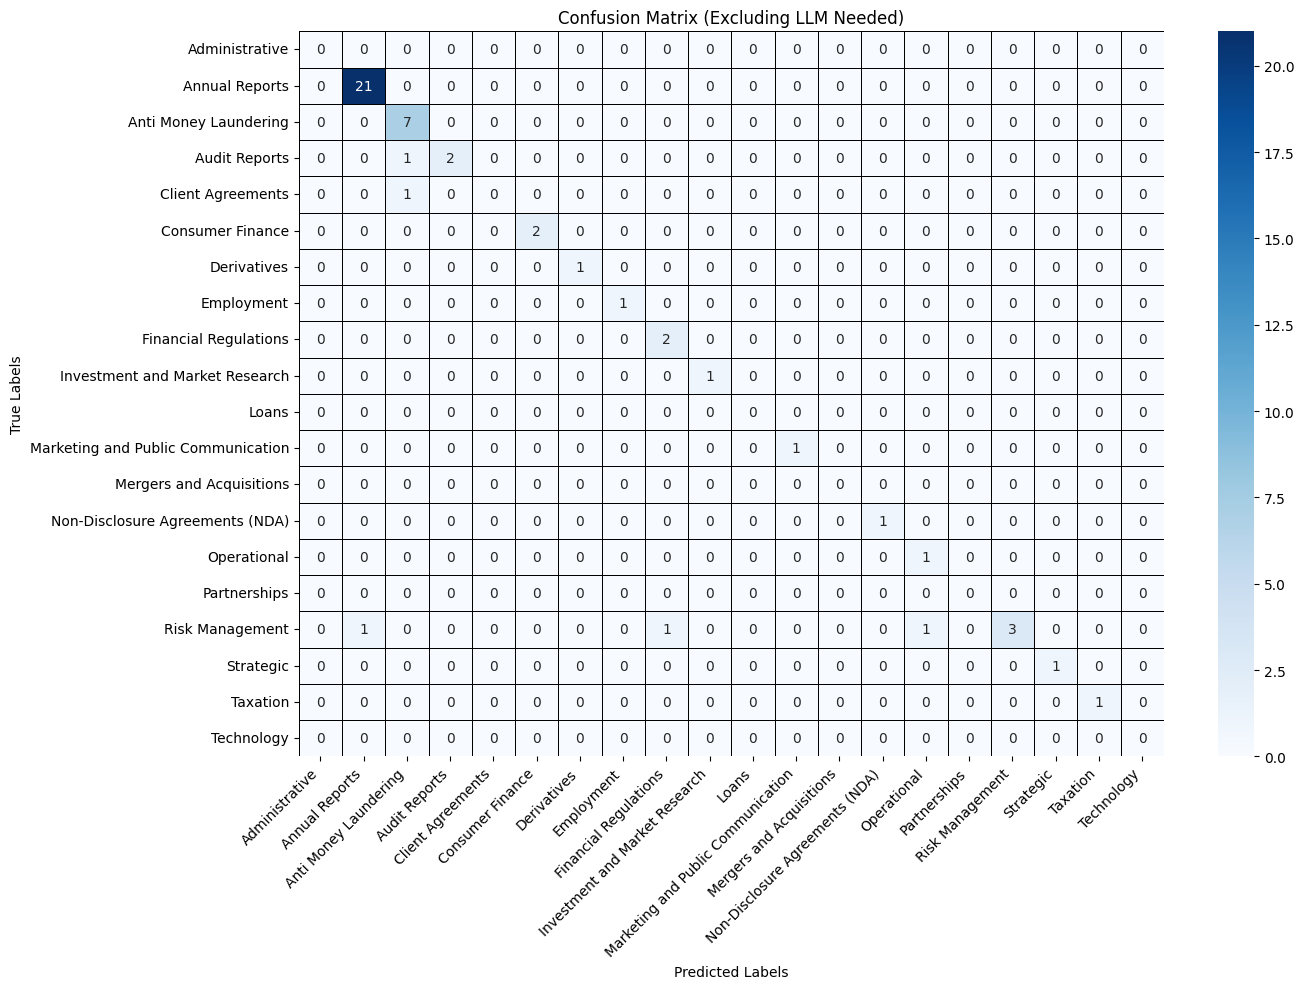

Model Training & Classification Complete!


In [6]:

import os
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import RFE
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN
from nltk.tokenize import word_tokenize
import joblib

# ** Load & Preprocess Data**
print("Loading Refined TF-IDF Bigrams...")
tfidf_df = pd.read_csv("refined_tfidf_bigrams_v5.csv")  
topics = tfidf_df.index.tolist()

# Tokenization function
def tokenize_text(text):
    """Tokenizes text into words and bigrams."""
    words = word_tokenize(text.lower())
    bigrams = [" ".join(pair) for pair in zip(words[:-1], words[1:])]
    return set(words + bigrams)

# ** Load & Process Documents**
print("Processing Documents...")
data_dir = "Extracted_Sample_Data"
documents, labels, filenames = [], [], []

for main_topic in os.listdir(data_dir):
    main_topic_path = os.path.join(data_dir, main_topic)
    
    if os.path.isdir(main_topic_path):  
        for root, _, files in os.walk(main_topic_path):  
            sub_topic = root.replace(data_dir + "/", "").strip()
            sub_topic_cleaned = sub_topic.split("/")[-1]  
            for file in files:
                if file.endswith(".txt"):
                    file_path = os.path.join(root, file)
                    
                    with open(file_path, "r", encoding="utf-8") as f:
                        content = f.read()
                    
                    documents.append(content)
                    labels.append(sub_topic_cleaned)
                    filenames.append(file)

# Convert to DataFrame
df = pd.DataFrame({"Filename": filenames, "Text": documents, "Label": labels})
print(f"Loaded {len(df)} documents for classification.")

# ** Extract TF-IDF Features**
print("Extracting TF-IDF Features...")
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,  # Increase features for better context
    max_df=0.85,
    min_df=2,  # Reduce requirement for minimum occurrences
    ngram_range=(1, 3)  # **Use trigrams for better phrase detection**
)

X = tfidf_vectorizer.fit_transform(df["Text"])
y = df["Label"]

# **Split into 80% Train / 20% Test**
X_train, X_test, y_train, y_test, filenames_train, filenames_test = train_test_split(
    X, y, filenames, test_size=0.2, stratify=y, random_state=42
)

# ** Apply Combined Resampling Strategy**
print("Applying combined resampling strategy...")
smote = SMOTE(random_state=42, k_neighbors=1)
ros = RandomOverSampler(random_state=42)

# Apply SMOTEENN to combine SMOTE and RandomOverSampler
smote_enn = SMOTEENN(smote=smote, random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)

# ** Apply Recursive Feature Elimination (RFE)**
print("Applying Recursive Feature Elimination (RFE)...")
rf_model = RandomForestClassifier(
    n_estimators=5000,  # Best Parameter
    max_depth=30,  # Best Parameter
    min_samples_split=2,  # Best Parameter
    min_samples_leaf=2,  # Best Parameter
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rfe = RFE(estimator=rf_model, n_features_to_select=5000, step=100)
X_train_rfe = rfe.fit_transform(X_train_resampled, y_train_resampled)
X_test_rfe = rfe.transform(X_test)

# ** Apply 10-Fold Cross-Validation**
print("Performing 10-Fold Cross-Validation...")
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X_train_rfe, y_train_resampled, cv=cv, scoring="precision_macro", n_jobs=-1)
print(f"Cross-validation precision_macro scores: {cv_scores}")
print(f"Mean Precision (macro): {cv_scores.mean():.4f}")

# **Train the Model After Cross-Validation**
print("Training Final Random Forest Model...")
rf_model.fit(X_train_rfe, y_train_resampled)

# ** Ensure Model is Fully Trained Before Calibration**
print("Calibrating Model with Isotonic Regression...")
calibrated_rf = CalibratedClassifierCV(rf_model, method="isotonic", cv="prefit")
calibrated_rf.fit(X_train_rfe, y_train_resampled)

# Save the calibrated model to a .pkl file
timestamp = time.strftime("%Y%m%d_%H%M%S")
model_filename = f"calibrated_rf_model_{timestamp}.pkl"
joblib.dump(calibrated_rf, model_filename)
print(f"Model saved as {model_filename}")

# ** Classify Test Documents**
print("Classifying Test Documents...")
y_pred_proba = calibrated_rf.predict_proba(X_test_rfe)  # Get probability scores
confidence_threshold = 0.75  # **Higher Confidence Required**

y_pred_final = []
confidence_scores = []
for i, probs in enumerate(y_pred_proba):
    max_prob = max(probs)
    
    # **Classify only when confidence is very high**
    if max_prob < confidence_threshold:
        y_pred_final.append("LLM Needed")  # Defer to LLM
        confidence_scores.append(max_prob)
    else:
        y_pred_final.append(calibrated_rf.classes_[np.argmax(probs)])
        confidence_scores.append(max_prob)

# ** Store Classification Results**
df_results = pd.DataFrame({
    "Filename": filenames_test,
    "Actual Topic": y_test.values,
    "Predicted Topic": y_pred_final,
    "Confidence Score": confidence_scores
})
df_results.to_csv(f"classification_results_{timestamp}.csv", index=False)
print(f"Classification results saved as classification_results_{timestamp}.csv")

# ** Compute LLM Needed Documents**
llm_needed = df_results[df_results["Predicted Topic"] == "LLM Needed"]
llm_needed_percentage = len(llm_needed) / len(df_results) * 100
no_classified_documents = df_results[df_results["Predicted Topic"] != "LLM Needed"]
classified_percentage = len(no_classified_documents) / len(df_results) * 100

print(f"{len(llm_needed)} documents ({llm_needed_percentage:.2f}%) require LLM intervention.")
print(f"{len(no_classified_documents)} documents ({classified_percentage:.2f}%) were classified with high confidence.")

# ** Evaluate Model (Excluding LLM Deferrals)**
df_filtered = df_results[df_results["Predicted Topic"] != "LLM Needed"]
filtered_actual = df_filtered["Actual Topic"]
filtered_predicted = df_filtered["Predicted Topic"]

print("Evaluating Model (Excluding LLM Needed)...")
report = classification_report(filtered_actual, filtered_predicted, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.to_csv(f"classification_metrics_{timestamp}.csv", index=True)
print("\nClassification Report:")
print(df_report)

# Confusion Matrix
plt.figure(figsize=(14, 10))
conf_matrix = confusion_matrix(filtered_actual, filtered_predicted, labels=calibrated_rf.classes_)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=calibrated_rf.classes_, 
            yticklabels=calibrated_rf.classes_,
            linewidths=0.5, linecolor='black')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (Excluding LLM Needed)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"confusion_matrix_{timestamp}.png")
plt.show()

print("Model Training & Classification Complete!")

# Model Retraining on Feedback

ok
Loaded 359 documents for classification.
test1
test2
test3
test4
fit RFE
fit_transform problem
test problem fitting
test5
test6
                                    precision    recall  f1-score   support

                    Administrative       0.17      1.00      0.29         1
                    Annual Reports       1.00      0.96      0.98        23
             Anti Money Laundering       0.38      0.71      0.50         7
                     Audit Reports       0.50      0.50      0.50         4
                 Client Agreements       0.00      0.00      0.00         3
                  Consumer Finance       0.50      1.00      0.67         2
                       Derivatives       1.00      1.00      1.00         1
                        Employment       1.00      1.00      1.00         1
             Financial Regulations       0.00      0.00      0.00         3
    Investment and Market Research       0.67      1.00      0.80         2
                             Loa

/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ivan

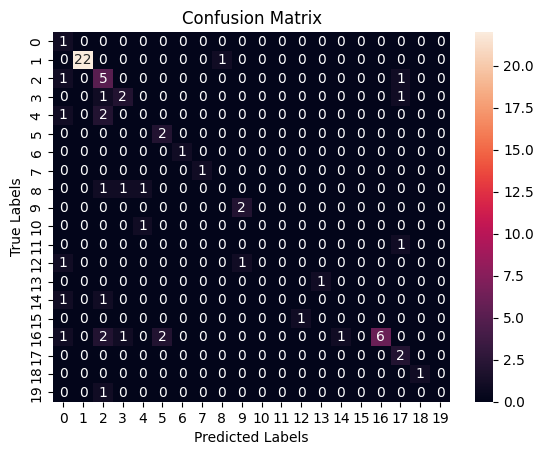

New model saved as rf_model_20250323_112804.pkl


In [ ]:
import os
import pandas as pd
import shutil
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import RFE
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from pypdf import PdfReader
import re
from nltk.corpus import stopwords
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Preprocessing functions
def clean_text(text):
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII characters
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters and numbers
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    text = re.sub(r'\n+', '\n', text)  # Remove extra newlines
    return text

def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

def preprocess_pdf(file_path):
    try:
        reader = PdfReader(file_path)
        extracted_text = ""
        for page in reader.pages:
            text = page.extract_text()
            if text:
                extracted_text += text + "\n"
        cleaned_text = clean_text(extracted_text)
        final_text = remove_stop_words(cleaned_text)
        return final_text
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Load initial data
vectorizer = joblib.load('tfidf_vectorizer.pkl')
model = joblib.load('rf_model.pkl')
feedback_df = pd.read_csv('user_feedback.csv')
mapping_df = pd.read_csv('final_file_topic_mapping_v6.csv')

# Process documents based on user feedback
document_dir = 'Extracted_Sample_Data'
for index, row in feedback_df.iterrows():
    try:
        file_name = row['name']
        corrected_topic = row['user_corrected_category']
        # Search for the file name without extension
        search_name = file_name.split('.')[0]
        # Find the corresponding .txt file in the document directory
        file_path = next((os.path.join(root, f) for root, dirs, files in os.walk(document_dir) 
                          for f in files if f.startswith(search_name) and f.endswith('.txt')), None)
        if file_path:
            # Determine the correct directory for the file
            current_directory = os.path.dirname(file_path)
            correct_directory = os.path.join(document_dir, corrected_topic)
            
            # Check if directory exists; if not, it could be nested
            if not os.path.exists(correct_directory):
                # Assuming nested folders format "Main/Category"
                for main_dir in os.listdir(document_dir):
                    potential_path = os.path.join(document_dir, main_dir, corrected_topic)
                    if os.path.exists(potential_path):
                        correct_directory = potential_path
                        break

            # Move the file to the correct directory if it's not already there
            if current_directory != correct_directory:
                os.makedirs(correct_directory, exist_ok=True)
                new_file_path = os.path.join(correct_directory, os.path.basename(file_path))
                shutil.move(file_path, new_file_path)
                print(f"Moved '{file_name}' to '{correct_directory}'")
        else:
            print(f"File not found for processing: {file_name}")
    except Exception as e:
        print(f"Error processing file {file_name}: {e}")

# Save updated mapping
mapping_df.to_csv('final_file_topic_mapping_v6.csv', index=False)

# Reload documents from updated Extracted_Sample_Data
documents, labels, filenames = [], [], []
for main_topic in os.listdir(document_dir):
    main_topic_path = os.path.join(document_dir, main_topic)
    
    if os.path.isdir(main_topic_path):  
        for root, _, files in os.walk(main_topic_path):  
            sub_topic = root.replace(document_dir + "/", "").strip()
            sub_topic_cleaned = sub_topic.split("/")[-1]  
            for file in files:
                if file.endswith(".txt"):
                    file_path = os.path.join(root, file)
                    
                    with open(file_path, "r", encoding="utf-8") as f:
                        content = f.read()
                    
                    documents.append(content)
                    labels.append(sub_topic_cleaned)
                    filenames.append(file)
print("ok")
df = pd.DataFrame({"Filename": filenames, "Text": documents, "Label": labels})
print(f"Loaded {len(df)} documents for classification.")

# Vectorize and prepare data
X = vectorizer.fit_transform(documents)
y = df["Label"]
print("test1")
# Train-test split
X_train, X_test, y_train, y_test, filenames_train, filenames_test = train_test_split(
    X, y, filenames, test_size=0.2, stratify=y, random_state=42
)
print("test2")
# Resampling

smote = SMOTE(random_state=42, k_neighbors=1)
ros = RandomOverSampler(random_state=42)
print("test3")
# Apply SMOTEENN to combine SMOTE and RandomOverSampler
smote_enn = SMOTEENN(smote=smote, random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)
print("test4")
rf_model = RandomForestClassifier(
    n_estimators=100,  # Best Parameter
    max_depth=10,  # Best Parameter
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
# Feature selection and model retraining
rfe = RFE(estimator=rf_model, n_features_to_select=500,step=250)
print("fit RFE")
X_train_rfe = rfe.fit_transform(X_resampled, y_resampled)
print("fit_transform problem")
X_test_rfe = rfe.transform(X_test)

print("test problem fitting")
rf_model.fit(X_train_rfe, y_resampled)
print("test5")
# Calibrate model
calibrated_rf = CalibratedClassifierCV(rf_model, method='isotonic', cv='prefit')
calibrated_rf.fit(X_train_rfe, y_resampled)
print("test6")
# Predict and evaluate
y_pred = calibrated_rf.predict(X_test_rfe)
print(classification_report(y_test, y_pred))
print("test7")
# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Save the new model
timestamp = time.strftime("%Y%m%d_%H%M%S")
model_filename = f"rf_model_{timestamp}.pkl"
joblib.dump(calibrated_rf, model_filename)
print(f"New model saved as {model_filename}")


Removed RFE, Recursive Factor Elimination as it was too computationally intensive.

Loaded 359 documents for classification.


/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Classification results saved as classification_results_20250323_125933.csv
23 documents (31.94%) require LLM intervention.
49 documents (68.06%) were classified with high confidence.
Evaluating Model (Excluding LLM Needed)...

Classification Report:
                                    precision    recall  f1-score    support
Administrative                       0.000000  0.000000  0.000000   0.000000
Annual Reports                       1.000000  1.000000  1.000000  22.000000
Anti Money Laundering                1.000000  1.000000  1.000000   5.000000
Audit Reports                        1.000000  1.000000  1.000000   1.000000
Client Agreements                    1.000000  1.000000  1.000000   1.000000
Consumer Finance                     1.000000  1.000000  1.000000   2.000000
Employment                           1.000000  1.000000  1.000000   1.000000
Financial Regulations                1.000000  1.000000  1.000000   2.000000
Investment and Market Research       1.000000  1.000000  

/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average

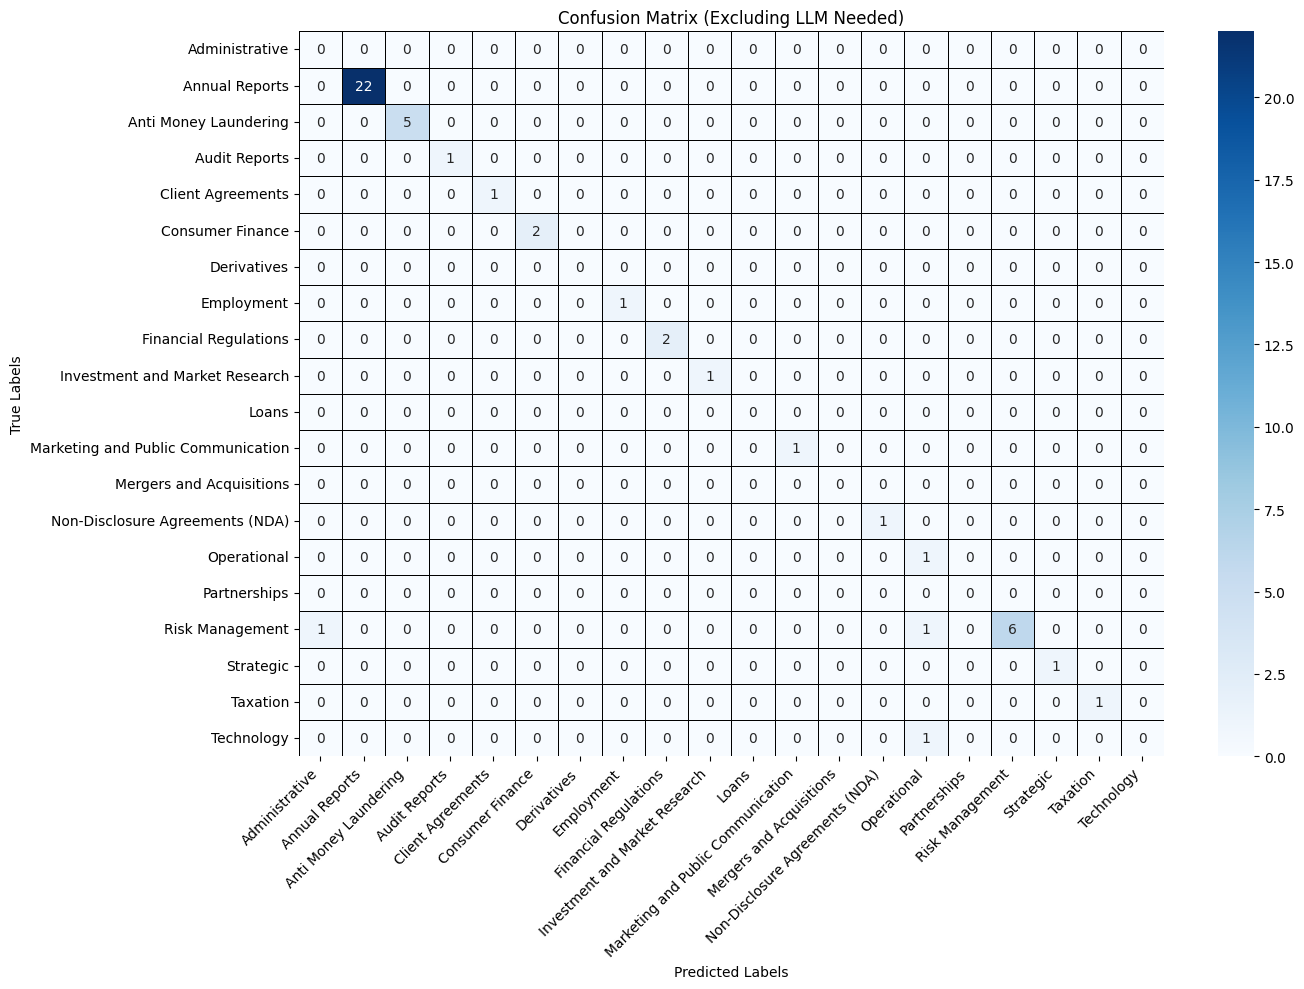

Model Training & Classification Complete!
New model saved as rf_model_20250323_130151.pkl


In [36]:
import os
import pandas as pd
import shutil
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import RFE
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from pypdf import PdfReader
import re
from nltk.corpus import stopwords
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Preprocessing functions
def clean_text(text):
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII characters
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters and numbers
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    text = re.sub(r'\n+', '\n', text)  # Remove extra newlines
    return text

def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

def preprocess_pdf(file_path):
    try:
        reader = PdfReader(file_path)
        extracted_text = ""
        for page in reader.pages:
            text = page.extract_text()
            if text:
                extracted_text += text + "\n"
        cleaned_text = clean_text(extracted_text)
        final_text = remove_stop_words(cleaned_text)
        return final_text
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Load initial data
vectorizer = joblib.load('tfidf_vectorizer.pkl')
model = joblib.load('rf_model.pkl')
feedback_df = pd.read_csv('user_feedback.csv')
mapping_df = pd.read_csv('final_file_topic_mapping_v6.csv')

# Process documents based on user feedback
document_dir = 'Extracted_Sample_Data'
for index, row in feedback_df.iterrows():
    try:
        file_name = row['name']
        corrected_topic = row['user_corrected_category']
        # Search for the file name without extension
        search_name = file_name.split('.')[0]
        # Find the corresponding .txt file in the document directory
        file_path = next((os.path.join(root, f) for root, dirs, files in os.walk(document_dir)
                          for f in files if f.startswith(search_name) and f.endswith('.txt')), None)
        if file_path:
            # Determine the correct directory for the file
            current_directory = os.path.dirname(file_path)
            correct_directory = os.path.join(document_dir, corrected_topic)
            
            # Check if directory exists; if not, it could be nested
            if not os.path.exists(correct_directory):
                # Assuming nested folders format "Main/Category"
                for main_dir in os.listdir(document_dir):
                    potential_path = os.path.join(document_dir, main_dir, corrected_topic)
                    if os.path.exists(potential_path):
                        correct_directory = potential_path
                        break

            # Move the file to the correct directory if it's not already there
            if current_directory != correct_directory:
                os.makedirs(correct_directory, exist_ok=True)
                new_file_path = os.path.join(correct_directory, os.path.basename(file_path))
                shutil.move(file_path, new_file_path)
                print(f"Moved '{file_name}' to '{correct_directory}'")
        else:
            print(f"File not found for processing: {file_name}")
    except Exception as e:
        print(f"Error processing file {file_name}: {e}")

# Save updated mapping
mapping_df.to_csv('final_file_topic_mapping_v6.csv', index=False)

# Reload documents from updated Extracted_Sample_Data
documents, labels, filenames = [], [], []
for main_topic in os.listdir(document_dir):
    main_topic_path = os.path.join(document_dir, main_topic)
    
    if os.path.isdir(main_topic_path):  
        for root, _, files in os.walk(main_topic_path):  
            sub_topic = root.replace(document_dir + "/", "").strip()
            sub_topic_cleaned = sub_topic.split("/")[-1]  
            for file in files:
                if file.endswith(".txt"):
                    file_path = os.path.join(root, file)
                    
                    with open(file_path, "r", encoding="utf-8") as f:
                        content = f.read()
                    
                    documents.append(content)
                    labels.append(sub_topic_cleaned)
                    filenames.append(file)

df = pd.DataFrame({"Filename": filenames, "Text": documents, "Label": labels})
print(f"Loaded {len(df)} documents for classification.")

# Vectorize and prepare data
X = vectorizer.fit_transform(documents)
y = df["Label"]

# Train-test split
X_train, X_test, y_train, y_test, filenames_train, filenames_test = train_test_split(
    X, y, filenames, test_size=0.2, stratify=y, random_state=42
)

# Resampling
smote = SMOTE(random_state=42, k_neighbors=1)
ros = RandomOverSampler(random_state=42)

# Apply SMOTEENN to combine SMOTE and RandomOverSampler
smote_enn = SMOTEENN(smote=smote, random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)
rf_model = RandomForestClassifier(
    n_estimators=5000,  # Best Parameter
    max_depth=30,  # Best Parameter
    min_samples_split=2,  # Best Parameter
    min_samples_leaf=2,  # Best Parameter
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
# Feature selection and model retraining
# rfe = RFE(estimator=rf_model, n_features_to_select=5000,step=100)
# print("fit RFE")
# X_train_rfe = rfe.fit_transform(X_resampled, y_resampled)
# print("fit_transform problem")
# X_test_rfe = rfe.transform(X_test)

rf_model.fit(X_resampled, y_resampled)

# Calibrate model
calibrated_rf = CalibratedClassifierCV(rf_model, method='isotonic', cv='prefit')
calibrated_rf.fit(X_resampled, y_resampled)

# Predict and evaluate
y_pred_proba = calibrated_rf.predict_proba(X_test)  # Get probability scores
confidence_threshold = 0.75  # **Higher Confidence Required**
y_pred_final = []
confidence_scores = []
for i, probs in enumerate(y_pred_proba):
    max_prob = max(probs)
    
    # **Classify only when confidence is very high**
    if max_prob < confidence_threshold:
        y_pred_final.append("LLM Needed")  # Defer to LLM
        confidence_scores.append(max_prob)
    else:
        y_pred_final.append(calibrated_rf.classes_[np.argmax(probs)])
        confidence_scores.append(max_prob)

# ** Store Classification Results**
df_results = pd.DataFrame({
    "Filename": filenames_test,
    "Actual Topic": y_test.values,
    "Predicted Topic": y_pred_final,
    "Confidence Score": confidence_scores
})
df_results.to_csv(f"classification_results_{timestamp}.csv", index=False)
print(f"Classification results saved as classification_results_{timestamp}.csv")

# ** Compute LLM Needed Documents**
llm_needed = df_results[df_results["Predicted Topic"] == "LLM Needed"]
llm_needed_percentage = len(llm_needed) / len(df_results) * 100
no_classified_documents = df_results[df_results["Predicted Topic"] != "LLM Needed"]
classified_percentage = len(no_classified_documents) / len(df_results) * 100

print(f"{len(llm_needed)} documents ({llm_needed_percentage:.2f}%) require LLM intervention.")
print(f"{len(no_classified_documents)} documents ({classified_percentage:.2f}%) were classified with high confidence.")

# ** Evaluate Model (Excluding LLM Deferrals)**
df_filtered = df_results[df_results["Predicted Topic"] != "LLM Needed"]
filtered_actual = df_filtered["Actual Topic"]
filtered_predicted = df_filtered["Predicted Topic"]

print("Evaluating Model (Excluding LLM Needed)...")
report = classification_report(filtered_actual, filtered_predicted, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.to_csv(f"classification_metrics_{timestamp}.csv", index=True)
print("\nClassification Report:")
print(df_report)

# Confusion Matrix
plt.figure(figsize=(14, 10))
conf_matrix = confusion_matrix(filtered_actual, filtered_predicted, labels=calibrated_rf.classes_)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=calibrated_rf.classes_, 
            yticklabels=calibrated_rf.classes_,
            linewidths=0.5, linecolor='black')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (Excluding LLM Needed)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"confusion_matrix_{timestamp}.png")
plt.show()

print("Model Training & Classification Complete!")
# Save the new model
timestamp = time.strftime("%Y%m%d_%H%M%S")
model_filename = f"rf_model_{timestamp}.pkl"
joblib.dump(calibrated_rf, model_filename)
print(f"New model saved as {model_filename}")

### Retraining Code without the Evaluation Metrics

In [35]:
import os
import pandas as pd
import shutil
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import RFE
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from pypdf import PdfReader
import re
from nltk.corpus import stopwords
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Preprocessing functions
def clean_text(text):
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove non-ASCII characters
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters and numbers
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    text = re.sub(r'\n+', '\n', text)  # Remove extra newlines
    return text

def remove_stop_words(text):
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

def preprocess_pdf(file_path):
    try:
        reader = PdfReader(file_path)
        extracted_text = ""
        for page in reader.pages:
            text = page.extract_text()
            if text:
                extracted_text += text + "\n"
        cleaned_text = clean_text(extracted_text)
        final_text = remove_stop_words(cleaned_text)
        return final_text
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Load initial data
vectorizer = joblib.load('tfidf_vectorizer.pkl')
model = joblib.load('rf_model.pkl')
feedback_df = pd.read_csv('user_feedback.csv')
mapping_df = pd.read_csv('final_file_topic_mapping_v6.csv')

# Process documents based on user feedback
document_dir = 'Extracted_Sample_Data'
for index, row in feedback_df.iterrows():
    try:
        file_name = row['name']
        corrected_topic = row['user_corrected_category']
        # Search for the file name without extension
        search_name = file_name.split('.')[0]
        # Find the corresponding .txt file in the document directory
        file_path = next((os.path.join(root, f) for root, dirs, files in os.walk(document_dir)
                          for f in files if f.startswith(search_name) and f.endswith('.txt')), None)
        if file_path:
            # Determine the correct directory for the file
            current_directory = os.path.dirname(file_path)
            correct_directory = os.path.join(document_dir, corrected_topic)
            
            # Check if directory exists; if not, it could be nested
            if not os.path.exists(correct_directory):
                # Assuming nested folders format "Main/Category"
                for main_dir in os.listdir(document_dir):
                    potential_path = os.path.join(document_dir, main_dir, corrected_topic)
                    if os.path.exists(potential_path):
                        correct_directory = potential_path
                        break

            # Move the file to the correct directory if it's not already there
            if current_directory != correct_directory:
                os.makedirs(correct_directory, exist_ok=True)
                new_file_path = os.path.join(correct_directory, os.path.basename(file_path))
                shutil.move(file_path, new_file_path)
                print(f"Moved '{file_name}' to '{correct_directory}'")
        else:
            print(f"File not found for processing: {file_name}")
    except Exception as e:
        print(f"Error processing file {file_name}: {e}")

# Save updated mapping
mapping_df.to_csv('final_file_topic_mapping_v6.csv', index=False)

# Reload documents from updated Extracted_Sample_Data
documents, labels, filenames = [], [], []
for main_topic in os.listdir(document_dir):
    main_topic_path = os.path.join(document_dir, main_topic)
    
    if os.path.isdir(main_topic_path):  
        for root, _, files in os.walk(main_topic_path):  
            sub_topic = root.replace(document_dir + "/", "").strip()
            sub_topic_cleaned = sub_topic.split("/")[-1]  
            for file in files:
                if file.endswith(".txt"):
                    file_path = os.path.join(root, file)
                    
                    with open(file_path, "r", encoding="utf-8") as f:
                        content = f.read()
                    
                    documents.append(content)
                    labels.append(sub_topic_cleaned)
                    filenames.append(file)

df = pd.DataFrame({"Filename": filenames, "Text": documents, "Label": labels})
print(f"Loaded {len(df)} documents for classification.")

# Vectorize and prepare data
X = vectorizer.fit_transform(documents)
y = df["Label"]

# No train-test split, use entire dataset
X_train = X
y_train = y

# Resampling
smote = SMOTE(random_state=42, k_neighbors=1)
ros = RandomOverSampler(random_state=42)

# Apply SMOTEENN to combine SMOTE and RandomOverSampler
smote_enn = SMOTEENN(smote=smote, random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train, y_train)

rf_model = RandomForestClassifier(
    n_estimators=5000,  # Best Parameter
    max_depth=30,  # Best Parameter
    min_samples_split=2,  # Best Parameter
    min_samples_leaf=2,  # Best Parameter
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
print("Training model")
rf_model.fit(X_resampled, y_resampled)

# Calibrate model
print("Calibrating Model")
calibrated_rf = CalibratedClassifierCV(rf_model, method='isotonic', cv='prefit')
calibrated_rf.fit(X_resampled, y_resampled)
print("Model training and calibration complete")

# Save the new model
timestamp = time.strftime("%Y%m%d_%H%M%S")
model_filename = f"rf_model_{timestamp}.pkl"
joblib.dump(calibrated_rf, model_filename)
print(f"New model saved as {model_filename}")


Moved 'SFLCBReg.pdf' to 'Extracted_Sample_Data/Regulatory and Compliance/Financial Regulations'
Loaded 359 documents for classification.
Training model
Calibrating Model


/Users/ivan/Documents/University/Y4S2/FYP/.venv/lib/python3.10/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Model training and calibration complete
New model saved as rf_model_20250323_125933.pkl
